# Tech Challenge 1 — Etapa 1: Entendimento e Preparação

**Previsão de Churn em Telecomunicações**

Este notebook cobre a Etapa 1 do projeto:
- Exploração de dados (EDA) completa: volume, qualidade, distribuição, data readiness.
- Definição de métricas técnicas e de negócio.
- Treinamento de baselines (`DummyClassifier` e Regressão Logística).
- Registro dos experimentos no MLflow.

> O ML Canvas do projeto está documentado separadamente em `docs/ml_canvas.md`.


## 1. Setup e imports

In [1]:
import sys
sys.path.insert(0, "../src")

import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import mlflow
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    RocCurveDisplay,
    accuracy_score,
    average_precision_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from churn_prediction.config import (
    MLFLOW_EXPERIMENT_NAME,
    MLFLOW_TRACKING_URI,
    RAW_DATASET_PATH,
    SEED,
    TARGET_COLUMN,
    set_global_seed,
)

set_global_seed(SEED)
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
print(f"Seed fixada em: {SEED}")


Seed fixada em: 42


## 2. Carga dos dados

Dataset: **Telco Customer Churn (IBM)** — disponível publicamente, contendo dados
demográficos, de serviços contratados e de cobrança de 7.043 clientes de uma
operadora de telecomunicações fictícia.


In [2]:
df = pd.read_csv(RAW_DATASET_PATH)
print(f"Shape: {df.shape[0]} linhas x {df.shape[1]} colunas")
df.head()


Shape: 7043 linhas x 21 colunas


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 3. Data Readiness — Volume, Qualidade e Tipos

Critério mínimo do desafio: ≥ 5.000 registros e ≥ 10 features. O dataset
atende com folga (7.043 registros, 20 features + target).


In [3]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [4]:
# Checagem de duplicados pelo identificador do cliente
print(f"customerID duplicados: {df['customerID'].duplicated().sum()}")

# Checagem de nulos explícitos (NaN)
print("\nNulos (NaN) por coluna:")
print(df.isnull().sum()[df.isnull().sum() > 0] if df.isnull().sum().sum() > 0 else "Nenhum NaN encontrado.")


customerID duplicados: 0

Nulos (NaN) por coluna:
Nenhum NaN encontrado.


**Achado de qualidade de dados #1 — `TotalCharges`:** a coluna está tipada como
`object` em vez de numérica. Isso acontece porque alguns registros têm o valor
representado como string vazia (`" "`), e não como `NaN` — por isso o
`isnull()` acima não os captura.


In [5]:
# TotalCharges está como string. Forçando conversão numérica para revelar os problemas.
total_charges_numeric = pd.to_numeric(df["TotalCharges"], errors="coerce")
mask_invalid = total_charges_numeric.isna()

print(f"Registros com TotalCharges não numérico: {mask_invalid.sum()}")
df.loc[mask_invalid, ["customerID", "tenure", "MonthlyCharges", "TotalCharges"]]


Registros com TotalCharges não numérico: 11


,customerID,tenure,MonthlyCharges,TotalCharges
488,4472-LVYGI,0,52.55,
753,3115-CZMZD,0,20.25,
936,5709-LVOEQ,0,80.85,
1082,4367-NUYAO,0,25.75,
1340,1371-DWPAZ,0,56.05,
3331,7644-OMVMY,0,19.85,
3826,3213-VVOLG,0,25.35,
4380,2520-SGTTA,0,20.00,
5218,2923-ARZLG,0,19.70,
6670,4075-WKNIU,0,73.35,


**Explicação:** todos os 11 registros problemáticos têm `tenure == 0`, ou seja,
são clientes recém-cadastrados que ainda não completaram um ciclo de cobrança.
Faz sentido de negócio que `TotalCharges` seja vazio nesse caso — **não é erro
de coleta, é uma regra de negócio implícita.**

**Decisão de tratamento:** converter `TotalCharges` para numérico e preencher
esses 11 casos com `0` (consistente com `tenure=0`), em vez de descartar as
linhas (perderíamos sinal, ainda que pequeno).


In [6]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce").fillna(0.0)
print("Tipo de TotalCharges após correção:", df["TotalCharges"].dtype)
print("Nulos restantes:", df["TotalCharges"].isnull().sum())


Tipo de TotalCharges após correção: float64
Nulos restantes: 0


**Achado de qualidade de dados #2 — `SeniorCitizen`:** está representado como
`int64` (0/1) enquanto as demais flags binárias (`Partner`, `Dependents`, etc.)
são strings `"Yes"/"No"`. Mantemos como está nesta etapa (o pipeline de
pré-processamento da Etapa 3 vai padronizar os tipos), mas registramos a
inconsistência.


## 4. Distribuição da variável-alvo (`Churn`)

Esse é o ponto mais importante da EDA para um problema de classificação: medir
o desbalanceamento de classes, que vai guiar a escolha de métrica técnica e a
estratégia de validação (estratificação obrigatória).


Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn
No     73.46
Yes    26.54
Name: proportion, dtype: float64


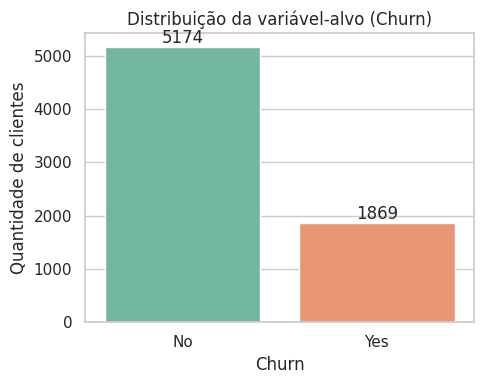

In [7]:
churn_counts = df[TARGET_COLUMN].value_counts()
churn_pct = df[TARGET_COLUMN].value_counts(normalize=True) * 100

print(churn_counts)
print()
print(churn_pct.round(2))

fig, ax = plt.subplots(figsize=(5, 4))
sns.countplot(data=df, x=TARGET_COLUMN, hue=TARGET_COLUMN, palette="Set2", legend=False, ax=ax)
ax.set_title("Distribuição da variável-alvo (Churn)")
ax.set_xlabel("Churn")
ax.set_ylabel("Quantidade de clientes")
for p in ax.patches:
    ax.annotate(f"{int(p.get_height())}", (p.get_x() + p.get_width() / 2, p.get_height()),
                ha="center", va="bottom")
plt.tight_layout()
plt.show()


**Achado central:** a base é **desbalanceada — aproximadamente 73,5% "No" vs.
26,5% "Yes"**. Isso tem implicações diretas:

- **Acurácia é uma métrica enganosa aqui**: um classificador "burro" que sempre
  prevê "No" já acerta ~73,5% das vezes sem aprender nada útil. Por isso o
  baseline `DummyClassifier` é incluído explicitamente — ele serve de "piso"
  de comparação.
- A validação cruzada **precisa ser estratificada** (`StratifiedKFold`), para
  que cada fold preserve a proporção de classes.
- Métricas mais informativas para este problema: **AUC-ROC, PR-AUC e F1**
  (a métrica técnica final é definida na Seção 5).


## 5. Métrica técnica e métrica de negócio

### Métrica técnica
Dado o desbalanceamento de classes, adotamos como métricas técnicas principais:

- **AUC-ROC**: mede a capacidade do modelo de separar as classes
  independentemente do threshold escolhido. Boa para comparar modelos.
- **PR-AUC (Average Precision)**: mais sensível ao desempenho na classe
  minoritária (churn) do que a AUC-ROC, especialmente relevante em bases
  desbalanceadas.
- **F1-score**: equilíbrio entre precisão e recall em um threshold fixo,
  relevante para a decisão operacional final (quem entra na campanha de
  retenção).

### Métrica de negócio
A diretoria quer reduzir o **custo de churn evitado**. Propomos um framework
de custo simples, parametrizável, baseado na matriz de confusão:

- **Falso Negativo (FN)** — cliente que vai cancelar e o modelo não identificou:
  custo = perda da receita do cliente (estimamos como `12 × MonthlyCharges`,
  ou seja, um ano de receita perdida).
- **Falso Positivo (FP)** — cliente que não ia cancelar, mas o modelo sinalizou
  risco e a empresa investiu em retenção (desconto, ligação, oferta): custo
  estimado como um valor fixo de campanha (ex.: R$ 50,00 por contato).
- **Verdadeiro Positivo (TP)** — cliente que ia cancelar e foi retido a tempo:
  ganho = receita preservada menos custo da campanha.

Esse framework será aplicado na Etapa 2, quando comparamos modelos sob a
ótica de custo, não apenas de métricas estatísticas.


## 6. Distribuições das variáveis numéricas

In [8]:
numeric_cols = ["tenure", "MonthlyCharges", "TotalCharges"]
df[numeric_cols].describe().T


,count,mean,std,min,25%,50%,75%,max
tenure,7043.0,32.371149,24.559481,0.00,9.00,29.00,55.00,72.00
MonthlyCharges,7043.0,64.761692,30.090047,18.25,35.50,70.35,89.85,118.75
TotalCharges,7043.0,2279.734304,2266.794470,0.00,398.55,1394.55,3786.60,8684.80


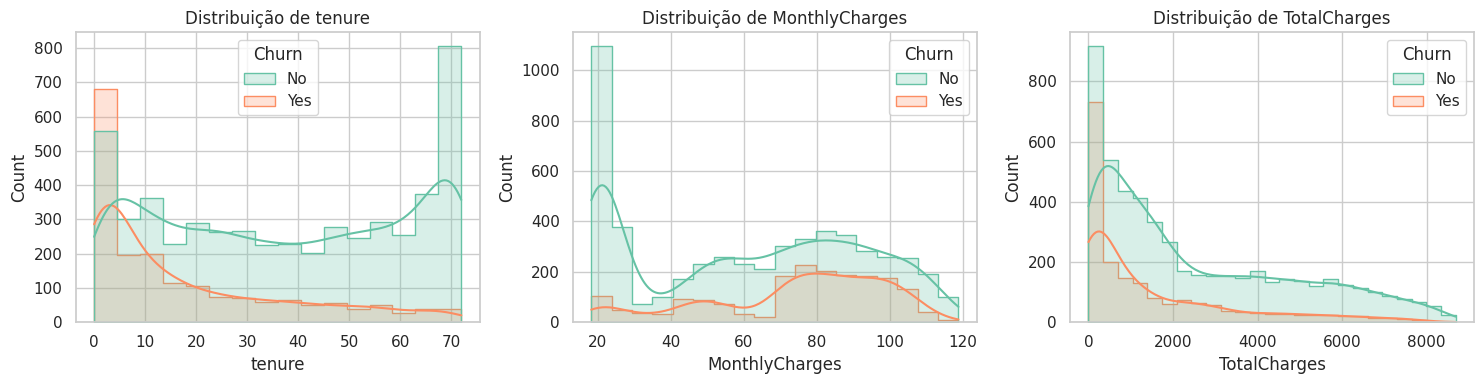

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, numeric_cols):
    sns.histplot(data=df, x=col, hue=TARGET_COLUMN, kde=True, ax=ax, palette="Set2", element="step")
    ax.set_title(f"Distribuição de {col}")
plt.tight_layout()
plt.show()


**Achados:**
- `tenure` (meses de contrato) tem uma concentração visível de clientes com
  pouco tempo de casa, e o churn é claramente mais frequente nessa faixa
  (confirmado na análise de churn por faixa de tenure, abaixo).
- `MonthlyCharges` mostra uma cauda de clientes com cobranças mais altas tendo
  maior proporção de churn.
- `TotalCharges` é fortemente correlacionado com `tenure` (cliente mais antigo
  acumula mais cobrança total) — candidato a feature redundante/colinear.


## 7. Churn por variáveis categóricas-chave

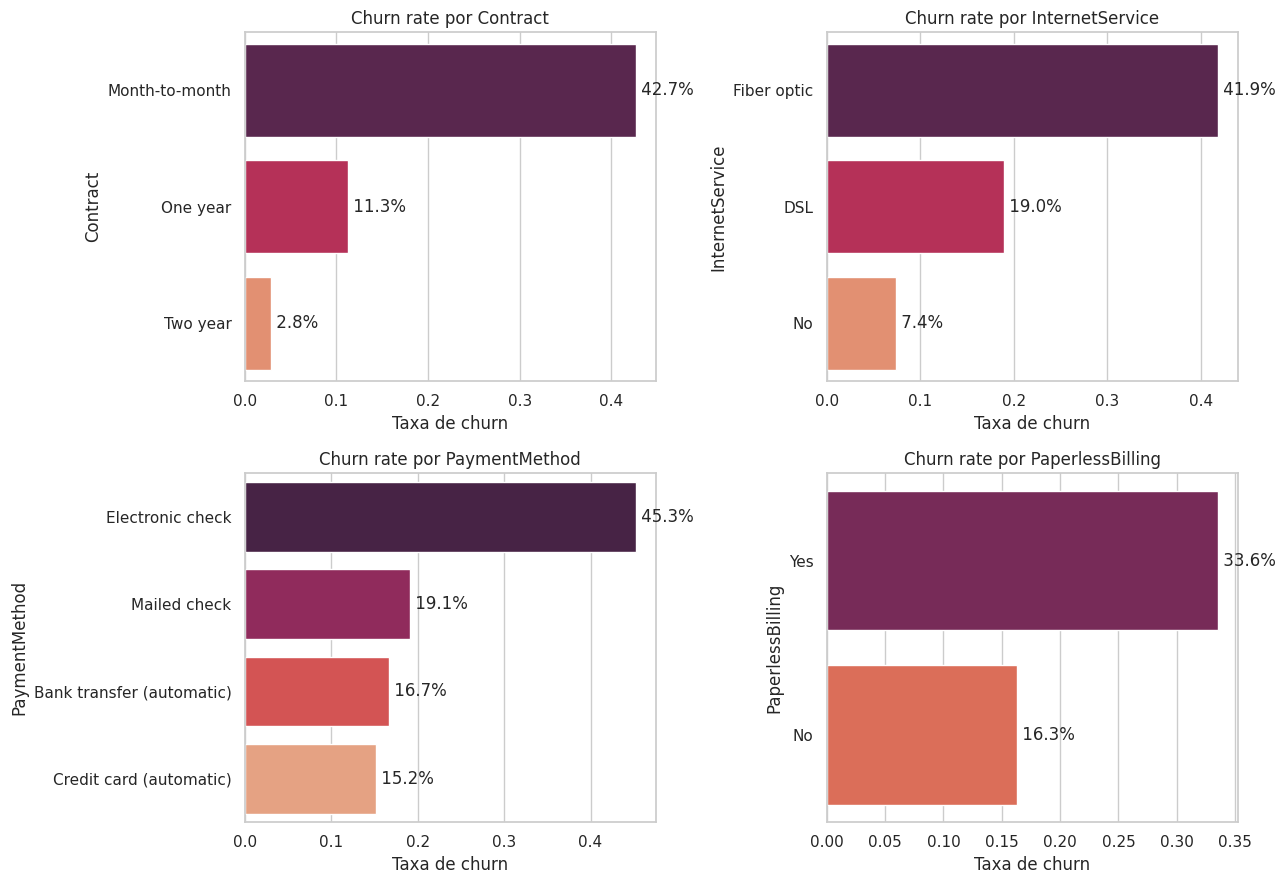

In [10]:
def churn_rate_by(col):
    return df.groupby(col)[TARGET_COLUMN].apply(lambda s: (s == "Yes").mean()).sort_values(ascending=False)


fig, axes = plt.subplots(2, 2, figsize=(13, 9))

for ax, col in zip(axes.flat, ["Contract", "InternetService", "PaymentMethod", "PaperlessBilling"]):
    rates = churn_rate_by(col)
    sns.barplot(x=rates.values, y=rates.index, ax=ax, palette="rocket", hue=rates.index, legend=False)
    ax.set_xlabel("Taxa de churn")
    ax.set_title(f"Churn rate por {col}")
    for i, v in enumerate(rates.values):
        ax.text(v, i, f" {v:.1%}", va="center")

plt.tight_layout()
plt.show()


**Achados de negócio mais relevantes:**

- **Tipo de contrato é o fator mais discriminante**: clientes `Month-to-month`
  têm taxa de churn de **~42,7%**, contra **~11,3%** em contratos de 1 ano e
  apenas **~2,8%** em contratos de 2 anos. Sugere fortemente que o **tipo de
  contrato deve ser feature central** no modelo.
- **Fibra óptica tem o dobro do churn da DSL** (~41,9% vs. ~19,0%), e clientes
  sem internet têm a menor taxa (~7,4%) — possivelmente porque o serviço de
  fibra é mais caro e/ou tem mais problemas de qualidade percebida.
- **Electronic check é o método de pagamento com churn muito mais alto**
  (~45,3%) comparado a métodos automáticos (cartão de crédito ~15,2%,
  transferência bancária ~16,7%) — pode indicar um perfil de cliente menos
  engajado ou processos de pagamento mais sujeitos a fricção/inadimplência.


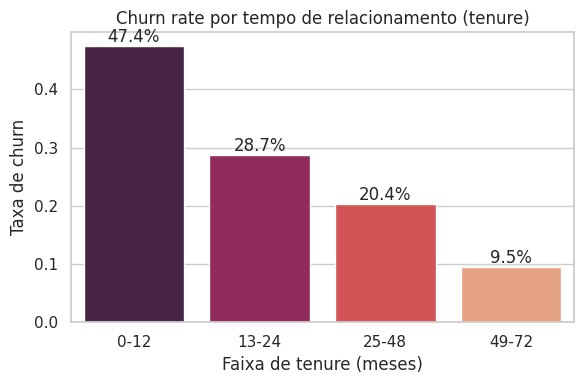

In [11]:
df["tenure_bucket"] = pd.cut(
    df["tenure"], bins=[-1, 12, 24, 48, 72], labels=["0-12", "13-24", "25-48", "49-72"]
)
tenure_churn = df.groupby("tenure_bucket", observed=True)[TARGET_COLUMN].apply(lambda s: (s == "Yes").mean())

fig, ax = plt.subplots(figsize=(6, 4))
sns.barplot(x=tenure_churn.index, y=tenure_churn.values, hue=tenure_churn.index, palette="rocket", legend=False, ax=ax)
ax.set_ylabel("Taxa de churn")
ax.set_xlabel("Faixa de tenure (meses)")
ax.set_title("Churn rate por tempo de relacionamento (tenure)")
for i, v in enumerate(tenure_churn.values):
    ax.text(i, v, f"{v:.1%}", ha="center", va="bottom")
plt.tight_layout()
plt.show()

df.drop(columns=["tenure_bucket"], inplace=True)


**Achado:** a taxa de churn cai de forma quase monotônica com o tempo de
relacionamento — de **~47,4%** nos primeiros 12 meses para **~9,5%** após 49
meses. Isso é consistente com o padrão clássico de "churn de boas-vindas":
clientes recém-adquiridos são o segmento de maior risco e o foco natural de
qualquer estratégia de retenção precoce.


## 8. Correlação entre variáveis numéricas

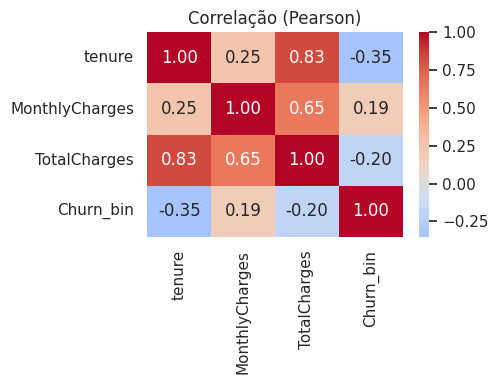

In [12]:
corr_df = df[["tenure", "MonthlyCharges", "TotalCharges"]].copy()
corr_df["Churn_bin"] = (df[TARGET_COLUMN] == "Yes").astype(int)

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(corr_df.corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Correlação (Pearson)")
plt.tight_layout()
plt.show()


**Achado:** `tenure` e `TotalCharges` são fortemente correlacionados (esperado,
já que `TotalCharges` é aproximadamente o produto de `tenure` por
`MonthlyCharges`). Isso é um ponto de atenção para a Etapa 2 — colinearidade
pode afetar a interpretabilidade de modelos lineares, embora tenha menor
impacto na rede neural (MLP). `tenure` tem a maior correlação (negativa) com
o churn entre as variáveis numéricas.


## 9. Preparação para modelagem: split treino/teste

Reservamos um holdout de teste (20%) **estratificado** pela variável-alvo, que
não será tocado até a avaliação final de modelos na Etapa 2.


In [13]:
X = df.drop(columns=["customerID", TARGET_COLUMN])
y = (df[TARGET_COLUMN] == "Yes").astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=SEED
)

print(f"Treino: {X_train.shape[0]} amostras | Teste: {X_test.shape[0]} amostras")
print(f"Taxa de churn no treino: {y_train.mean():.3f} | Taxa de churn no teste: {y_test.mean():.3f}")


Treino: 5634 amostras | Teste: 1409 amostras
Taxa de churn no treino: 0.265 | Taxa de churn no teste: 0.265


## 10. Pipeline de pré-processamento (Scikit-Learn)

Pipeline simples reutilizável: imputação + escala para numéricas, one-hot
para categóricas. Este mesmo `ColumnTransformer` será reaproveitado como base
do pipeline refatorado na Etapa 3.


In [14]:
numeric_features = ["tenure", "MonthlyCharges", "TotalCharges"]
categorical_features = [c for c in X.columns if c not in numeric_features]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore", drop="if_binary"), categorical_features),
    ]
)
preprocessor


,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. `

## 11. Baselines: DummyClassifier e Regressão Logística

Treinamos dois baselines com **validação cruzada estratificada (k=5)**:

1. **DummyClassifier** (estratégia `stratified`): o "piso" — gera previsões
   respeitando a proporção das classes, sem nenhum aprendizado real. Qualquer
   modelo que não supere isso não tem valor preditivo.
2. **Regressão Logística**: baseline linear interpretável, comum em modelos
   de churn na indústria.


In [15]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)


def evaluate_cv(pipeline, X, y, cv):
    """Avalia um pipeline via CV estratificada, retornando métricas médias."""
    metrics = {"roc_auc": [], "pr_auc": [], "f1": [], "precision": [], "recall": [], "accuracy": []}

    for train_idx, val_idx in cv.split(X, y):
        X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]

        pipeline.fit(X_tr, y_tr)
        y_pred = pipeline.predict(X_val)
        y_proba = pipeline.predict_proba(X_val)[:, 1]

        metrics["roc_auc"].append(roc_auc_score(y_val, y_proba))
        metrics["pr_auc"].append(average_precision_score(y_val, y_proba))
        metrics["f1"].append(f1_score(y_val, y_pred))
        metrics["precision"].append(precision_score(y_val, y_pred, zero_division=0))
        metrics["recall"].append(recall_score(y_val, y_pred))
        metrics["accuracy"].append(accuracy_score(y_val, y_pred))

    return {k: (np.mean(v), np.std(v)) for k, v in metrics.items()}


In [16]:
dummy_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", DummyClassifier(strategy="stratified", random_state=SEED)),
])

dummy_metrics = evaluate_cv(dummy_pipeline, X_train, y_train, cv)

print("DummyClassifier — métricas médias (CV 5-fold estratificada):")
for metric, (mean, std) in dummy_metrics.items():
    print(f"  {metric:10s}: {mean:.4f} +/- {std:.4f}")


DummyClassifier — métricas médias (CV 5-fold estratificada):
  roc_auc   : 0.5065 +/- 0.0171
  pr_auc    : 0.2686 +/- 0.0071
  f1        : 0.2762 +/- 0.0249
  precision : 0.2748 +/- 0.0248
  recall    : 0.2776 +/- 0.0250
  accuracy  : 0.6139 +/- 0.0133


In [17]:
logreg_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000, random_state=SEED, class_weight="balanced")),
])

logreg_metrics = evaluate_cv(logreg_pipeline, X_train, y_train, cv)

print("Regressão Logística — métricas médias (CV 5-fold estratificada):")
for metric, (mean, std) in logreg_metrics.items():
    print(f"  {metric:10s}: {mean:.4f} +/- {std:.4f}")


Regressão Logística — métricas médias (CV 5-fold estratificada):
  roc_auc   : 0.8460 +/- 0.0124
  pr_auc    : 0.6600 +/- 0.0195
  f1        : 0.6293 +/- 0.0223
  precision : 0.5178 +/- 0.0186
  recall    : 0.8027 +/- 0.0360
  accuracy  : 0.7492 +/- 0.0150


**Leitura esperada dos resultados:** a Regressão Logística deve superar
claramente o `DummyClassifier` em AUC-ROC e PR-AUC, validando que há sinal
preditivo real nos dados — esse é o "gate" mínimo de qualidade antes de
avançarmos para a rede neural na Etapa 2.


## 12. Registro dos experimentos no MLflow

Registramos parâmetros, métricas e a versão do dataset para os dois baselines,
estabelecendo o histórico de experimentos que será expandido na Etapa 2 com a
MLP em PyTorch.


In [18]:
mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)
mlflow.set_experiment(MLFLOW_EXPERIMENT_NAME)

dataset_version = "telco-customer-churn-ibm-v1"


def log_baseline_run(run_name, pipeline, metrics_dict, extra_params=None):
    with mlflow.start_run(run_name=run_name):
        mlflow.log_param("seed", SEED)
        mlflow.log_param("dataset_version", dataset_version)
        mlflow.log_param("n_train_samples", X_train.shape[0])
        mlflow.log_param("n_features_raw", X_train.shape[1])
        mlflow.log_param("cv_strategy", "StratifiedKFold(n_splits=5)")
        if extra_params:
            mlflow.log_params(extra_params)

        for metric, (mean, std) in metrics_dict.items():
            mlflow.log_metric(f"{metric}_mean", mean)
            mlflow.log_metric(f"{metric}_std", std)

        # Treina no full train set para registrar o modelo como artefato
        pipeline.fit(X_train, y_train)
        mlflow.sklearn.log_model(pipeline, name="model")

        print(f"Run '{run_name}' registrada no MLflow.")


log_baseline_run(
    "baseline_dummy_classifier",
    dummy_pipeline,
    dummy_metrics,
    extra_params={"strategy": "stratified"},
)

log_baseline_run(
    "baseline_logistic_regression",
    logreg_pipeline,
    logreg_metrics,
    extra_params={"class_weight": "balanced", "max_iter": 1000},
)


2026/06/27 14:16:07 INFO mlflow.store.db.utils: Creating initial MLflow database tables...


2026/06/27 14:16:07 INFO mlflow.store.db.utils: Updating database tables


2026/06/27 14:16:08 INFO mlflow.tracking.fluent: Experiment with name 'churn-prediction' does not exist. Creating a new experiment.


Run 'baseline_dummy_classifier' registrada no MLflow.


Run 'baseline_logistic_regression' registrada no MLflow.


In [19]:
print(f"Experimentos registrados em: {MLFLOW_TRACKING_URI}")
print("Para visualizar: execute `mlflow ui --backend-store-uri", MLFLOW_TRACKING_URI, "` na raiz do projeto.")


Experimentos registrados em: sqlite:////home/claude/FIAP_MLE10_TC1/mlflow.db
Para visualizar: execute `mlflow ui --backend-store-uri sqlite:////home/claude/FIAP_MLE10_TC1/mlflow.db ` na raiz do projeto.


## 13. Resumo da Etapa 1 e próximos passos

**Resumo dos achados:**

1. Dataset com 7.043 registros e 20 features, sem nulos explícitos, mas com
   11 registros de `TotalCharges` vazio (clientes com `tenure=0`) — tratado
   via imputação para `0`.
2. Target desbalanceado (~73,5% / ~26,5%) → exige CV estratificada e métricas
   robustas a desbalanceamento (AUC-ROC, PR-AUC, F1), não apenas acurácia.
3. Variáveis com maior poder discriminante identificadas: `Contract`,
   `InternetService`, `tenure`, `PaymentMethod`.
4. Baselines (`DummyClassifier` e Regressão Logística) treinados, avaliados
   via CV estratificada e registrados no MLflow.

**Próximos passos (Etapa 2):** construir e treinar a MLP em PyTorch, comparar
com os baselines desta etapa usando ≥ 4 métricas, e analisar o trade-off de
custo entre falsos positivos e falsos negativos.
